©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、PyTorchを用いてDCGAN（Deep Convolutional GAN）を実装し、画像生成を行います。転置畳み込みによるGeneratorと畳み込みによるDiscriminatorを構築し、敵対的学習によってリアルな画像が生成されていく過程を学びます。

# 事前準備

[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）


In [ ]:
%%capture
!pip uninstall matplotlib -y
!pip install matplotlib==3.9.4

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.11.0.86

!pip uninstall torch -y
!pip install torch==2.7.0

!pip uninstall torchvision -y
!pip install torchvision==0.22.0

# DCGANの作成

## GANによる画像生成の準備ファイル

In [ ]:
import os
import urllib.request
import zipfile
import tarfile

import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
import numpy as np

In [ ]:
# フォルダ「data」が存在しない場合は作成する
data_dir = "./data/"
if not os.path.exists(data_dir):
    os.mkdir(data_dir)

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
# MNISTの手書き数字画像をダウンロードし読み込む
from sklearn.datasets import fetch_openml

#mnist = fetch_openml('mnist_784', version=1, data_home="./data/")
mnist = fetch_openml('mnist_784', version=1, data_home="./data/", as_frame=False)

In [ ]:
# データの取り出し
X = mnist.data
y = mnist.target

この画像データのラベルは5です


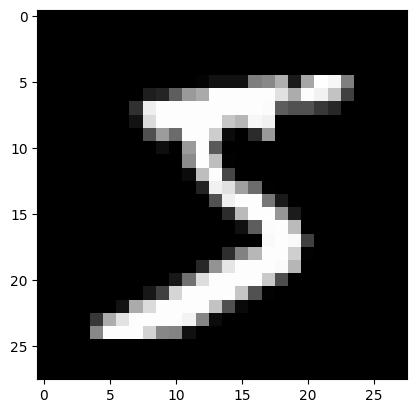

In [ ]:
# MNISTのデータの1つ目を可視化する
plt.imshow(X[0].reshape(28, 28), cmap='gray')
print("この画像データのラベルは{}です".format(y[0]))

In [ ]:
# フォルダ「data」の下にフォルダ「img」を作成する
data_dir_path = "./data/img/"
if not os.path.exists(data_dir_path):
    os.mkdir(data_dir_path)

In [ ]:
# MNISTから数字7、8の画像だけフォルダ「img」に画像として保存していく
count7=0
count8=0
max_num=200  # 画像は200枚ずつ作成する

for i in range(len(X)):

    # 画像7の作成
    if (y[i] is "7") and (count7<max_num):
        file_path="./data/img/img_7_"+str(count7)+".jpg"
        im_f=(X[i].reshape(28, 28))  # 画像を28×28の形に変形
        pil_img_f = Image.fromarray(im_f.astype(np.uint8))  # 画像をPILに
        pil_img_f = pil_img_f.resize((64, 64), Image.BICUBIC)  # 64×64に拡大
        pil_img_f.save(file_path)  # 保存
        count7+=1

    # 画像8の作成
    if (y[i] is "8") and (count8<max_num):
        file_path="./data/img/img_8_"+str(count8)+".jpg"
        im_f=(X[i].reshape(28, 28))  # 画像を28*28の形に変形
        pil_img_f = Image.fromarray(im_f.astype(np.uint8))  # 画像をPILに
        pil_img_f = pil_img_f.resize((64, 64), Image.BICUBIC)  # 64×64に拡大
        pil_img_f.save(file_path)  # 保存
        count8+=1

<>:9: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:18: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:9: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:18: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipython-input-3579521295.py:9: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if (y[i] is "7") and (count7<max_num):
/tmp/ipython-input-3579521295.py:18: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if (y[i] is "8") and (count8<max_num):


## 事前準備

In [ ]:
# パッケージのimport
import random
import math
import time
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.utils.data as data
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import transforms

In [ ]:
# Setup seeds
torch.manual_seed(1234)
np.random.seed(1234)
random.seed(1234)

## 転置畳み込みの例

In [ ]:
input = torch.tensor([[[[1., 1.], [2., 2.]]]])
# 入力テンソル。形状は (バッチ=1, チャネル=1, 高さ=2, 幅=2)
# 値は [[1,1],[2,2]] の1チャネル画像を1枚だけ持っているイメージ
print("入力データ")
print(input)
print("-----")

print("通常の畳み込み")
m = nn.Conv2d(1, 1, 2, stride=1, bias=False)
# Conv2d(in_channels=1, out_channels=1, カーネルサイズ=2x2)
# stride=1 なので「普通の畳み込み」。paddingは未指定なので0
# bias=False にしてバイアス項なし
m.weight.data[0, 0, 0, 0] = 1
m.weight.data[0, 0, 0, 1] = 2
m.weight.data[0, 0, 1, 0] = 3
m.weight.data[0, 0, 1, 1] = 4
# カーネル(フィルタ)の中身を手動で設定

print("カーネル")
print(m.weight)
print("出力")
print(m(input))

print("-----")
print("転置畳み込み")
m = nn.ConvTranspose2d(1, 1, 2, stride=1, bias=False)
m.weight.data[0, 0, 0, 0] = 1
m.weight.data[0, 0, 0, 1] = 2
m.weight.data[0, 0, 1, 0] = 3
m.weight.data[0, 0, 1, 1] = 4
# ConvTranspose2d のフィルタ内容も同じく [[1,2],[3,4]] に揃える

print("カーネル")
print(m.weight)
print("出力")
print(m(input))

入力データ
tensor([[[[1., 1.],
          [2., 2.]]]])
-----
通常の畳み込み
カーネル
Parameter containing:
tensor([[[[1., 2.],
          [3., 4.]]]], requires_grad=True)
出力
tensor([[[[17.]]]], grad_fn=<ConvolutionBackward0>)
-----
転置畳み込み
カーネル
Parameter containing:
tensor([[[[1., 2.],
          [3., 4.]]]], requires_grad=True)
出力
tensor([[[[ 1.,  3.,  2.],
          [ 5., 13.,  8.],
          [ 6., 14.,  8.]]]], grad_fn=<ConvolutionBackward0>)


## Generatorの実装

In [ ]:
class Generator(nn.Module):

    def __init__(self, z_dim=20, image_size=64):
        super(Generator, self).__init__()

        self.layer1 = nn.Sequential(
            nn.ConvTranspose2d(z_dim, image_size * 8,
                               kernel_size=4, stride=1),
            # z_dim(潜在次元) を チャネル数 image_size*8 に変換しつつ
            # 出力の空間サイズを 1x1 → 4x4 にする
            nn.BatchNorm2d(image_size * 8),
            nn.ReLU(inplace=True))

        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(image_size * 8, image_size * 4,
                               kernel_size=4, stride=2, padding=1),
            # 4x4 → 8x8 にアップサンプリング
            nn.BatchNorm2d(image_size * 4),
            nn.ReLU(inplace=True))

        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(image_size * 4, image_size * 2,
                               kernel_size=4, stride=2, padding=1),
            # 8x8 → 16x16
            nn.BatchNorm2d(image_size * 2),
            nn.ReLU(inplace=True))

        self.layer4 = nn.Sequential(
            nn.ConvTranspose2d(image_size * 2, image_size,
                               kernel_size=4, stride=2, padding=1),
            # 16x16 → 32x32
            nn.BatchNorm2d(image_size),
            nn.ReLU(inplace=True))

        self.last = nn.Sequential(
            nn.ConvTranspose2d(image_size, 1, kernel_size=4,
                               stride=2, padding=1),
            # 32x32 → 64x64
            nn.Tanh())
        # 白黒画像なので出力チャネルは1つ

    def forward(self, z):
        # z は (バッチ, z_dim, 1, 1) の形を想定する潜在ノイズ
        out = self.layer1(z)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.last(out)

        return out

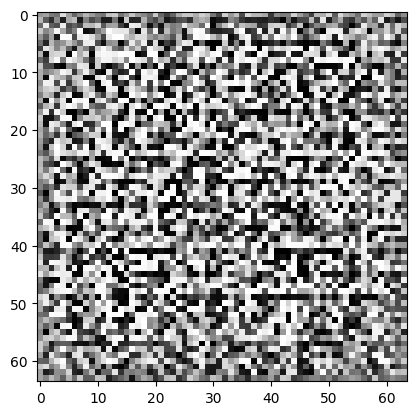

In [ ]:
# 動作確認
import matplotlib.pyplot as plt
%matplotlib inline

G = Generator(z_dim=20, image_size=64)
# 生成器をインスタンス化。z_dim=20 はノイズの次元、image_size=64 は基準チャネル数

# 入力する乱数
input_z = torch.randn(1, 20)
# 標準正規分布 N(0,1) からランダムノイズを1サンプル分作成
# 形は (バッチ=1, 次元=20)

# テンソルサイズを(1, 20, 1, 1)に変形
input_z = input_z.view(input_z.size(0), input_z.size(1), 1, 1)
# ConvTranspose2d は (N, C, H, W) 入力なので、(1,20,1,1) に reshape

# 偽画像を出力
fake_images = G(input_z)
# Generator でノイズから64x64の偽画像を生成

img_transformed = fake_images[0][0].detach().numpy()
# 先頭バッチ・先頭チャネルを取り出してCPU側numpyに変換

plt.imshow(img_transformed, 'gray')
plt.show()
# 生成画像をグレースケール表示して可視化

## Discriminatorの実装

In [ ]:
class Discriminator(nn.Module):

    def __init__(self, z_dim=20, image_size=64):
        super(Discriminator, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(1, image_size, kernel_size=4,
                      stride=2, padding=1),
            # 入力画像 (1,64,64) → (image_size,32,32)
            # ここはBatchNormを入れず LeakyReLU で非線形
            nn.LeakyReLU(0.1, inplace=True))
        # 注意：白黒画像なので入力チャネルは1つだけ

        self.layer2 = nn.Sequential(
            nn.Conv2d(image_size, image_size*2, kernel_size=4,
                      stride=2, padding=1),
            # 32x32 → 16x16
            nn.LeakyReLU(0.1, inplace=True))

        self.layer3 = nn.Sequential(
            nn.Conv2d(image_size*2, image_size*4, kernel_size=4,
                      stride=2, padding=1),
            # 16x16 → 8x8
            nn.LeakyReLU(0.1, inplace=True))

        self.layer4 = nn.Sequential(
            nn.Conv2d(image_size*4, image_size*8, kernel_size=4,
                      stride=2, padding=1),
            # 8x8 → 4x4
            nn.LeakyReLU(0.1, inplace=True))

        self.last = nn.Conv2d(image_size*8, 1, kernel_size=4, stride=1)
        # 4x4 → 1x1 に畳み込んでスカラーにする

    def forward(self, x):
        # x は (バッチ, 1, 64, 64) の画像を想定
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.last(out)

        return out

In [ ]:
# 動作確認
D = Discriminator(z_dim=20, image_size=64)

# 偽画像を生成
input_z = torch.randn(1, 20)
input_z = input_z.view(input_z.size(0), input_z.size(1), 1, 1)
fake_images = G(input_z)

# 偽画像をDに入力
d_out = D(fake_images)

# 出力d_outにSigmoidをかけて0から1に変換
print(nn.Sigmoid()(d_out))

tensor([[[[0.5014]]]], grad_fn=<SigmoidBackward0>)


## DataLoaderの作成

In [ ]:
def make_datapath_list():
    """学習、検証の画像データとアノテーションデータへのファイルパスリストを作成する。 """

    train_img_list = list()  # 画像ファイルパスを格納

    for img_idx in range(200):
        img_path = "./data/img/img_7_" + str(img_idx)+'.jpg'
        train_img_list.append(img_path)

        img_path = "./data/img/img_8_" + str(img_idx)+'.jpg'
        train_img_list.append(img_path)

    return train_img_list

In [ ]:
class ImageTransform():
    """画像の前処理クラス"""

    def __init__(self, mean, std):
        self.data_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
            # 画素値を [-1,1] 付近に収めるための正規化。
        ])

    def __call__(self, img):
        return self.data_transform(img)

In [ ]:
class GAN_Img_Dataset(data.Dataset):
    """画像のDatasetクラス。PyTorchのDatasetクラスを継承"""

    def __init__(self, file_list, transform):
        self.file_list = file_list      # 画像パス一覧
        self.transform = transform      # 前処理(上のImageTransform)

    def __len__(self):
        '''画像の枚数を返す'''
        return len(self.file_list)

    def __getitem__(self, index):
        '''前処理をした画像のTensor形式のデータを取得'''

        img_path = self.file_list[index]
        img = Image.open(img_path)  # [高さ][幅]白黒

        # 画像の前処理
        img_transformed = self.transform(img)

        return img_transformed

In [ ]:
# DataLoaderの作成と動作確認

# ファイルリストを作成
train_img_list=make_datapath_list()

# Datasetを作成
mean = (0.5,)
std = (0.5,)
train_dataset = GAN_Img_Dataset(
    file_list=train_img_list, transform=ImageTransform(mean, std))
# 各画像を Tensor化＋(x-0.5)/0.5 で [-1,1] に近い範囲へ正規化する

# DataLoaderを作成
batch_size = 64

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True)
# バッチ化とシャッフルを行う。

# 動作の確認
batch_iterator = iter(train_dataloader)  # イテレータに変換
imges = next(batch_iterator)  # 1番目の要素を取り出す
print(imges.size())  # torch.Size([64, 1, 64, 64])

torch.Size([64, 1, 64, 64])


## 学習

In [ ]:
# ネットワークの初期化
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        # Conv2dとConvTranspose2dの初期化
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('BatchNorm') != -1:
        # BatchNorm2dの初期化
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# 初期化の実施
G.apply(weights_init)
D.apply(weights_init)

print("ネットワークの初期化完了")

ネットワークの初期化完了


In [ ]:
# モデルを学習させる関数を作成
def train_model(G, D, dataloader, num_epochs):

    # GPUが使えるかを確認
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("使用デバイス：", device)

    # 最適化手法の設定
    g_lr, d_lr = 0.0001, 0.0004
    beta1, beta2 = 0.0, 0.9
    g_optimizer = torch.optim.Adam(G.parameters(), g_lr, [beta1, beta2])
    d_optimizer = torch.optim.Adam(D.parameters(), d_lr, [beta1, beta2])

    # 誤差関数を定義
    criterion = nn.BCEWithLogitsLoss(reduction='mean')

    # パラメータをハードコーディング
    z_dim = 20
    mini_batch_size = 64

    # ネットワークをGPUへ
    G.to(device)
    D.to(device)

    G.train()  # モデルを訓練モードに
    D.train()  # モデルを訓練モードに

    # ネットワークがある程度固定であれば、高速化させる
    torch.backends.cudnn.benchmark = True

    # 画像の枚数
    num_train_imgs = len(dataloader.dataset)
    batch_size = dataloader.batch_size

    # イテレーションカウンタをセット
    iteration = 1
    logs = []

    # epochのループ
    for epoch in range(num_epochs):

        # 開始時刻を保存
        t_epoch_start = time.time()
        epoch_g_loss = 0.0  # epochの損失和
        epoch_d_loss = 0.0  # epochの損失和

        print('-------------')
        print('Epoch {}/{}'.format(epoch, num_epochs))
        print('-------------')
        print('（train）')

        # データローダーからminibatchずつ取り出すループ
        for imges in dataloader:

            # --------------------
            # 1. Discriminatorの学習
            # --------------------
            # ミニバッチがサイズが1だと、バッチノーマライゼーションでエラーになるのでさける
            # issue #186より不要なのでコメントアウト
            # if imges.size()[0] == 1:
            #     continue

            # GPUが使えるならGPUにデータを送る
            imges = imges.to(device)

            # 正解ラベルと偽ラベルを作成
            # epochの最後のイテレーションはミニバッチの数が少なくなる
            mini_batch_size = imges.size()[0]
            label_real = torch.full((mini_batch_size,), 1).to(device)
            label_fake = torch.full((mini_batch_size,), 0).to(device)

            # 真の画像を判定
            d_out_real = D(imges)

            # 偽の画像を生成して判定
            input_z = torch.randn(mini_batch_size, z_dim).to(device)
            input_z = input_z.view(input_z.size(0), input_z.size(1), 1, 1)
            fake_images = G(input_z)
            d_out_fake = D(fake_images)

            # 誤差を計算
            label_real = label_real.type_as(d_out_real.view(-1))
            d_loss_real = criterion(d_out_real.view(-1), label_real)
            label_fake = label_fake.type_as(d_out_fake.view(-1))
            d_loss_fake = criterion(d_out_fake.view(-1), label_fake)
            d_loss = d_loss_real + d_loss_fake

            # バックプロパゲーション
            g_optimizer.zero_grad()
            d_optimizer.zero_grad()

            d_loss.backward()
            d_optimizer.step()

            # --------------------
            # 2. Generatorの学習
            # --------------------
            # 偽の画像を生成して判定
            input_z = torch.randn(mini_batch_size, z_dim).to(device)
            input_z = input_z.view(input_z.size(0), input_z.size(1), 1, 1)
            fake_images = G(input_z)
            d_out_fake = D(fake_images)

            # 誤差を計算
            g_loss = criterion(d_out_fake.view(-1), label_real)

            # バックプロパゲーション
            g_optimizer.zero_grad()
            d_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

            # --------------------
            # 3. 記録
            # --------------------
            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()
            iteration += 1

        # epochのphaseごとのlossと正解率
        t_epoch_finish = time.time()
        print('-------------')
        print('epoch {} || Epoch_D_Loss:{:.4f} ||Epoch_G_Loss:{:.4f}'.format(
            epoch, epoch_d_loss/batch_size, epoch_g_loss/batch_size))
        print('timer:  {:.4f} sec.'.format(t_epoch_finish - t_epoch_start))
        t_epoch_start = time.time()

    return G, D

In [ ]:
# 学習・検証を実行
# 6分ほどかかる
num_epochs = 200
G_update, D_update = train_model(
    G, D, dataloader=train_dataloader, num_epochs=num_epochs)

使用デバイス： cuda:0
-------------
Epoch 0/200
-------------
（train）
-------------
epoch 0 || Epoch_D_Loss:0.0834 ||Epoch_G_Loss:0.1432
timer:  3.9782 sec.
-------------
Epoch 1/200
-------------
（train）
-------------
epoch 1 || Epoch_D_Loss:0.0339 ||Epoch_G_Loss:0.3373
timer:  0.5740 sec.
-------------
Epoch 2/200
-------------
（train）
-------------
epoch 2 || Epoch_D_Loss:0.0028 ||Epoch_G_Loss:0.5499
timer:  0.5749 sec.
-------------
Epoch 3/200
-------------
（train）
-------------
epoch 3 || Epoch_D_Loss:0.0522 ||Epoch_G_Loss:0.5806
timer:  0.5669 sec.
-------------
Epoch 4/200
-------------
（train）
-------------
epoch 4 || Epoch_D_Loss:0.1022 ||Epoch_G_Loss:0.0808
timer:  0.5672 sec.
-------------
Epoch 5/200
-------------
（train）
-------------
epoch 5 || Epoch_D_Loss:0.0697 ||Epoch_G_Loss:0.1494
timer:  0.5695 sec.
-------------
Epoch 6/200
-------------
（train）
-------------
epoch 6 || Epoch_D_Loss:0.0082 ||Epoch_G_Loss:0.3818
timer:  0.5800 sec.
-------------
Epoch 7/200
-------------


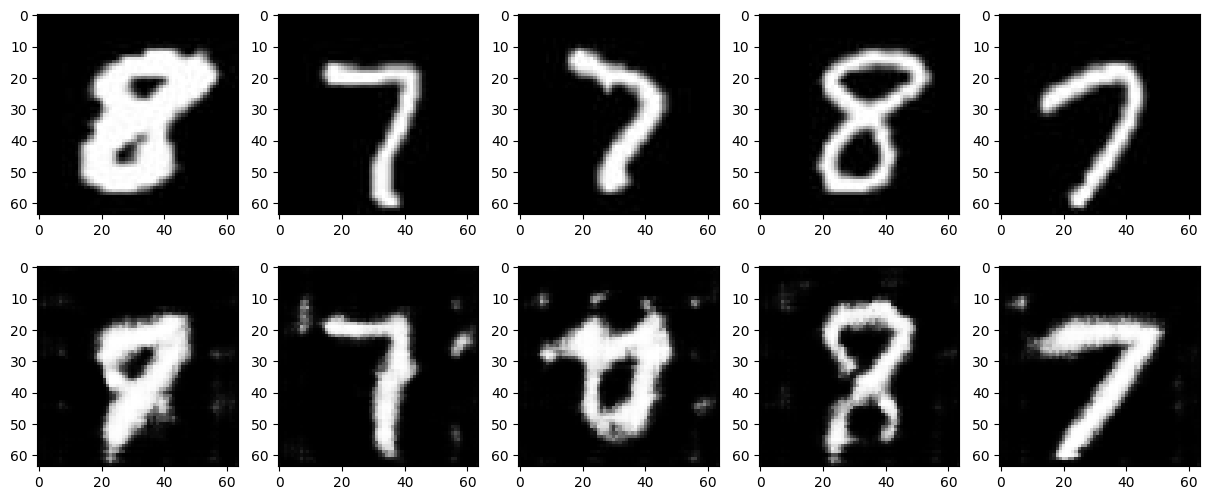

In [ ]:
# 生成画像と訓練データを可視化する
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 入力の乱数生成
batch_size = 8
z_dim = 20
fixed_z = torch.randn(batch_size, z_dim)
fixed_z = fixed_z.view(fixed_z.size(0), fixed_z.size(1), 1, 1)

# 画像生成
G_update.eval()
# eval() にしてBatchNormを推論モードにする（平均・分散固定）
fake_images = G_update(fixed_z.to(device))

# 訓練データ
batch_iterator = iter(train_dataloader)  # イテレータに変換
imges = next(batch_iterator)  # 1番目の要素を取り出す


# 出力
fig = plt.figure(figsize=(15, 6))
for i in range(0, 5):
    # 上段に訓練データを表示する
    plt.subplot(2, 5, i+1)
    plt.imshow(imges[i][0].cpu().detach().numpy(), 'gray')

    # 下段に生成データを表示する
    plt.subplot(2, 5, 5+i+1)
    plt.imshow(fake_images[i][0].cpu().detach().numpy(), 'gray')

## 🔧 実践問題1：ラベルスムージングでGANの学習を安定させる

上の学習コードでは、Discriminatorの正解ラベルに `1`（本物）と `0`（偽物）のハードラベルを使っています。
しかし、GANの学習ではDiscriminatorが強くなりすぎてGeneratorが学習できなくなる問題がよく起きます。

**ラベルスムージング**は、ハードラベルを少しだけ「ぼかす」ことでDiscriminatorの過信を防ぐ手法です：

| | ハードラベル | スムージング後 |
|:---|:---|:---|
| 本物画像のラベル | `1.0` | `0.7 〜 1.0` のランダム値 |
| 偽物画像のラベル | `0.0` | `0.0 〜 0.3` のランダム値 |

こうすることでDiscriminatorが「100%本物」と確信しにくくなり、Generatorにも学習の余地が残ります。

---

**問題：** 以下のコードの `______` を埋めて、ラベルスムージングを適用した学習ループを実装してください。

<br/>

<details>
<summary>💡 <b>ヒント（クリックして表示）</b></summary>

<blockquote>
<code>torch.rand()</code> は0〜1の一様乱数を返します。<code>0.7 + 0.3 * torch.rand(...)</code> で0.7〜1.0のランダム値が作れます。
</blockquote>

</details>

<br/>


In [ ]:
def train_with_label_smoothing(G, D, dataloader, num_epochs):
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    g_lr, d_lr = 0.0001, 0.0004
    beta1, beta2 = 0.0, 0.9
    g_optimizer = torch.optim.Adam(G.parameters(), g_lr, [beta1, beta2])
    d_optimizer = torch.optim.Adam(D.parameters(), d_lr, [beta1, beta2])
    criterion = nn.BCEWithLogitsLoss(reduction='mean')
    z_dim = 20

    G.to(device); D.to(device)
    G.train(); D.train()

    for epoch in range(num_epochs):
        epoch_d_loss, epoch_g_loss = 0.0, 0.0

        for imges in dataloader:
            imges = imges.to(device)
            mini_batch_size = imges.size()[0]

            # ラベルスムージング：本物ラベルを 0.7〜1.0 のランダム値にする
            label_real = ______ + ______ * torch.______(mini_batch_size,).to(device)
            # 偽物ラベルを 0.0〜0.3 のランダム値にする
            label_fake = ______ * torch.______(mini_batch_size,).to(device)

            # --- Discriminator ---
            d_out_real = D(imges)
            input_z = torch.randn(mini_batch_size, z_dim).to(device)
            input_z = input_z.view(input_z.size(0), input_z.size(1), 1, 1)
            fake_images = G(input_z)
            d_out_fake = D(fake_images)

            d_loss_real = criterion(d_out_real.view(-1), label_real)
            d_loss_fake = criterion(d_out_fake.view(-1), label_fake)
            d_loss = d_loss_real + d_loss_fake

            g_optimizer.zero_grad(); d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # --- Generator ---
            # Generatorの学習時は、偽画像を「本物」と判定させたい
            # → ラベルは 1.0（ここではスムージングしない）
            input_z = torch.randn(mini_batch_size, z_dim).to(device)
            input_z = input_z.view(input_z.size(0), input_z.size(1), 1, 1)
            fake_images = G(input_z)
            d_out_fake = D(fake_images)
            g_label = torch.______(mini_batch_size,).______(d_out_fake.view(-1)).to(device)
            g_loss = criterion(d_out_fake.view(-1), g_label)

            g_optimizer.zero_grad(); d_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        print(f'epoch {epoch} || D_loss:{epoch_d_loss/len(dataloader):.4f} || G_loss:{epoch_g_loss/len(dataloader):.4f}')

    return G, D


# 学習の実行（再初期化してから）
G_smooth = Generator(z_dim=20, image_size=64)
D_smooth = Discriminator(z_dim=20, image_size=64)
G_smooth.apply(weights_init)
D_smooth.apply(weights_init)

G_smooth, D_smooth = train_with_label_smoothing(G_smooth, D_smooth, dataloader, num_epochs=200)


<details><summary>解答例</summary>

```python
# 本物ラベル: 0.7 + 0.3 * rand → 0.7〜1.0
label_real = 0.7 + 0.3 * torch.rand(mini_batch_size,).to(device)

# 偽物ラベル: 0.3 * rand → 0.0〜0.3
label_fake = 0.3 * torch.rand(mini_batch_size,).to(device)

# Generatorの学習では 1.0 のハードラベルを使う
g_label = torch.ones(mini_batch_size,).type_as(d_out_fake.view(-1)).to(device)
```

- `0.7 + 0.3 * torch.rand(...)` で各サンプルに独立な0.7〜1.0のランダム値を生成します。`torch.full((...,), 1)` のハードラベルと比べて、Discriminatorが「絶対に本物」と確信しにくくなります
- 偽物ラベルも `0.3 * torch.rand(...)` で0.0〜0.3にスムージングします
- Generator側では `torch.ones(...)` で1.0のハードラベルを使います。Generatorの目標は「Discriminatorに本物と判定させること」なので、ここはぼかしません
- `.type_as(d_out_fake.view(-1))` はラベルのデータ型をDiscriminatorの出力に合わせるためのキャストです
- ラベルスムージングにより、Discriminatorが過剰に自信を持つことが抑制され、D/G間の学習バランスが改善される傾向があります
</details>


## 🔧 実践問題2：潜在空間の補間（Latent Space Interpolation）で画像を滑らかに変化させる

学習済みGeneratorは、潜在ベクトル `z`（ランダムな20次元ベクトル）を入力として画像を生成します。
2つの異なる `z` を用意し、その間を**線形補間**すると、生成される画像が滑らかに変化していきます。

```
z1 ──────────────── z2
 ↓     ↓     ↓     ↓
画像1  画像2  画像3  画像4
（数字7）            （数字8）
```

線形補間により、GANが学習した「潜在空間」が連続的で意味のある構造を持っているかを確認できます。

---

**問題：** 以下のコードの `______` を埋めて、2つの潜在ベクトル間を8段階で補間し、生成画像を並べて表示してください。

<br/>

<details>
<summary>💡 <b>ヒント（クリックして表示）</b></summary>

<blockquote>
<code>torch.linspace(0, 1, 8)</code> で0.0から1.0まで等間隔の8点を生成できます。
</blockquote>

</details>

<br/>


In [ ]:
import matplotlib.pyplot as plt

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
G_trained = G.to(device)
G_trained.eval()

# 2つのランダムな潜在ベクトルを生成
z_dim = 20
z1 = torch.randn(1, z_dim).to(device)
z2 = torch.randn(1, z_dim).to(device)

# 0.0 から 1.0 まで8段階の補間係数を生成
n_steps = 8
t_values = torch.______(0, 1, ______)

fig, axes = plt.subplots(1, n_steps, figsize=(16, 2))

for i, t in enumerate(t_values):
    # 線形補間
    z_interp = (______ - t) * z1 + ______ * z2

    # Generatorに入力する形に変形
    z_input = z_interp.view(1, z_dim, ______, ______)

    # 画像を生成（勾配計算は不要）
    with torch.______():
        fake_img = G_trained(z_input)

    # (1, 1, 64, 64) → (64, 64) に変換して表示
    img = fake_img.squeeze().cpu().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f't={t:.2f}')
    axes[i].axis('off')

plt.suptitle('Latent Space Interpolation')
plt.tight_layout()
plt.show()


<details><summary>解答例</summary>

```python
t_values = torch.linspace(0, 1, n_steps)

z_interp = (1 - t) * z1 + t * z2

z_input = z_interp.view(1, z_dim, 1, 1)

with torch.no_grad():
    fake_img = G_trained(z_input)
```

- `torch.linspace(0, 1, 8)` は `[0.0, 0.143, 0.286, ..., 1.0]` の8点を生成します
- `(1 - t) * z1 + t * z2` が線形補間の式です。`t=0` で `z1`、`t=1` で `z2`、中間値で両方の混合になります
- `.view(1, z_dim, 1, 1)` はGeneratorの入力形状 `(batch, channels, height, width)` に合わせる変形です。Generatorの最初の層 `ConvTranspose2d` が `(N, z_dim, 1, 1)` を期待しているためです
- `torch.no_grad()` は推論時に勾配計算を無効化し、メモリを節約します
- 画像が滑らかに変化していれば、潜在空間が**連続的で意味のある構造**を持っていることを意味します。急激に変化する場合は、潜在空間にギャップがある（モード崩壊の兆候）可能性があります
</details>
